# Kuhn Poker: CFR algorithm


## Sumary :

* [**1. Game model**](#1)
* [**2. Strategy notation**](#2)
* [**3. CFR state variables**](#3)
* [**4. Regret matching**](#4)
* [**5. Counterfactual recursion**](#5)
* [**6. Training loop**](#6)
* [**7. Average strategy**](#7)

* [**8. Probability evolution and experiment**](#8)

**Math objects**
- `h`: public action history
- `I`: information set `(player, private card, h)`
- `A(I)`: legal actions at `I`
- `σ_i(I,a)`: behavior strategy
- `π_i(h)`: reach probability of player `i`
- `R(I,a)`: cumulative counterfactual regret
- `S(I,a)`: cumulative strategy weight
- `u_i(z)`: terminal utility

**Sources**
- [Zinkevich et al. (2007), Regret Minimization in Games with Incomplete Information](https://poker.cs.ualberta.ca/publications/NIPS07-cfr.pdf)
- [Kuhn (1950), A simplified two-person poker](https://www.jstor.org/stable/2236819)
- [Neller & Lanctot (2013), An Introduction to Counterfactual Regret Minimization](http://modelai.gettysburg.edu/2013/cfr/cfr.pdf)


<a id='1'></a>
## 1. Game model
- Deck: `Ω = {(J,Q), (J,K), (Q,J), (Q,K), (K,J), (K,Q)}`
- Chance is uniform: `P(ω)=1/6`
- Zero-sum payoff: `u_1(z) = -u_0(z)`
- Terminal histories: `cc`, `bc`, `bf`, `cbc`, `cbf`


In [109]:
import engine # Import the Kuhn Poker engine module
import numpy as np

<a id='2'></a>
## 2. Strategy notation
- A strategy maps each information set `I` to probabilities over `A(I)`.
- Example: `P0|K| -> {c: 0.5, b: 0.5}`
- `run_game` samples one terminal history `z ~ σ`.


In [110]:
random_strategy_0 = {
    "P0|J|": {"c": 0.5, "b": 0.5},
    "P0|Q|": {"c": 0.5, "b": 0.5},
    "P0|K|": {"c": 0.5, "b": 0.5},

    "P0|J|cb": {"c": 0.5, "f": 0.5},
    "P0|Q|cb": {"c": 0.5, "f": 0.5},
    "P0|K|cb": {"c": 0.5, "f": 0.5},
}

random_strategy_1 = {
    "P1|J|c": {"c": 0.5, "b": 0.5},
    "P1|Q|c": {"c": 0.5, "b": 0.5},
    "P1|K|c": {"c": 0.5, "b": 0.5},

    "P1|J|b": {"c": 0.5, "f": 0.5},
    "P1|Q|b": {"c": 0.5, "f": 0.5},
    "P1|K|b": {"c": 0.5, "f": 0.5},
}

utility = engine.run_game(
    strategy_0=random_strategy_0,
    strategy_1=random_strategy_1,
    seed=42,
    verbose=True,
)

Cards: P0=J, P1=Q
P0|J|: {'c': 0.5, 'b': 0.5} -> c
P1|Q|c: {'c': 0.5, 'b': 0.5} -> b
P0|J|cb: {'c': 0.5, 'f': 0.5} -> f
History: cbf, utility P0: -1


<a id='3'></a>
## 3. CFR state variables
- `regret_sum[I][a] = R(I,a)`
- `strategy_sum[I][a] = S(I,a)`
- Both start at `0`.


In [111]:
regret_sum = {}
strategy_sum = {}

regret_sum["P0|K|"] = {
    "c": 0.0,
    "b": 0.0,
}

strategy_sum["P0|K|"] = {
    "c": 0.0,
    "b": 0.0,
}


### `initialize_infoset`
- Input: information set `I`, action set `A(I)`
- Creates `R(I,a)=0` and `S(I,a)=0`
- No game value is computed here


In [112]:
def initialize_infoset(key, actions):
    """Create zero vectors R(I, ·) and S(I, ·) for one information set."""
    if key not in regret_sum:
        regret_sum[key] = {
            action: 0.0 for action in actions
        }
        strategy_sum[key] = {
            action: 0.0 for action in actions
        }

<a id='4'></a>
## 4. Regret matching

### `get_strategy`
- Positive regret: `R⁺(I,a)=max(R(I,a),0)`
- If `Σ_a R⁺(I,a)>0`: `σ(I,a)=R⁺(I,a)/Σ_b R⁺(I,b)`
- Else: uniform distribution over `A(I)`


In [113]:
def get_strategy(key, actions):
    """Compute sigma(I) by regret matching: sigma(a) proportional to max(R(I,a), 0)."""
    initialize_infoset(key, actions)

    positive_regrets = {
        action: max(regret_sum[key][action], 0.0)
        for action in actions
    }

    total_regret = sum(positive_regrets.values())

    if total_regret > 0:
        return {
            action: positive_regrets[action] / total_regret
            for action in actions
        }

    uniform_probability = 1.0 / len(actions)

    return {
        action: uniform_probability
        for action in actions
    }

<a id='5'></a>
## 5. Counterfactual recursion

### `cfr`
- Terminal node: return `u_0(z)`
- Action value: `v_0(h,a)`
- Node value: `v_0(h)=Σ_a σ(I,a)v_0(h,a)`
- Player 0 regret: `v_0(h,a)-v_0(h)`
- Player 1 regret: `v_1(h,a)-v_1(h)=v_0(h)-v_0(h,a)`
- Weight regrets by opponent reach probability


### Intuition: what does CFR learn?

At an information set `I`, CFR compares every legal action with the value of the current mixed strategy.

- If `v(I,a) - v(I) > 0`, action `a` would have performed better: its cumulative regret increases.
- Regret matching gives more probability to actions with positive cumulative regret.
- `reach_p0` and `reach_p1` measure how likely each player made the current history reachable.
- The final policy is the reach-weighted average `σ̄`, which is more stable than the last instantaneous policy.

Small example: if the cumulative regrets of `check` and `bet` are `-1` and `3`, their positive parts are `0` and `3`; the next strategy therefore plays `bet` with probability `1`.


In [114]:
def cfr(state, reach_p0, reach_p1):
    """Return v_0(h) and update counterfactual regrets at I(h)."""
    if state.terminal:
        return state.utility(player=0)

    player = state.player
    key = state.infoset_key()
    actions = state.actions()
    strategy = get_strategy(key, actions)

    action_values = {}

    # Evaluate every legal action.
    for action in actions:
        child_state = state.child(action)

        if player == 0:
            action_values[action] = cfr(
                state=child_state,
                reach_p0=reach_p0 * strategy[action],
                reach_p1=reach_p1,
            )
        else:
            action_values[action] = cfr(
                state=child_state,
                reach_p0=reach_p0,
                reach_p1=reach_p1 * strategy[action],
            )

    # Compute the value of the current mixed strategy.
    node_value = sum(
        strategy[action] * action_values[action]
        for action in actions
    )

    # Update cumulative regrets and strategy sums.
    for action in actions:
        if player == 0:
            regret = action_values[action] - node_value

            regret_sum[key][action] += reach_p1 * regret
            strategy_sum[key][action] += reach_p0 * strategy[action]
        else:
            regret = node_value - action_values[action]

            regret_sum[key][action] += reach_p0 * regret
            strategy_sum[key][action] += reach_p1 * strategy[action]

    return node_value

<a id='6'></a>
## 6. Training loop

### `train_cfr`
- Iterates over every chance deal `ω ∈ Ω`
- Starts from empty history `h=""`
- Accumulates expected utility over chance
- Repeats for `T` iterations


In [ ]:
def train_cfr(number_iterations):
    """Average CFR updates over all chance deals omega in Omega."""
    utility_sum = 0.0

    for _ in range(number_iterations):
        iteration_utility = 0.0

        for cards in engine.OMEGA:
            initial_state = engine.State(
                cards=cards,
                history="",
            )

            iteration_utility += cfr(
                state=initial_state,
                reach_p0=1.0,
                reach_p1=1.0,
            )

        utility_sum += iteration_utility / len(engine.OMEGA)

    return utility_sum / number_iterations

## 7. Average strategy

### `get_average_strategy`
- Average policy uses cumulative weights:
- `σ̄(I,a)=S(I,a)/Σ_b S(I,b)`
- Uniform fallback when the denominator is `0`


In [116]:
def get_average_strategy():
    """Normalize S(I, ·) into the average strategy mean(omega(I))."""
    average_strategy = {}

    for key, action_sums in strategy_sum.items():
        total = sum(action_sums.values())

        if total > 0:
            average_strategy[key] = {
                action: value / total
                for action, value in action_sums.items()
            }
        else:
            uniform_probability = 1.0 / len(action_sums)

            average_strategy[key] = {
                action: uniform_probability
                for action in action_sums
            }

    return average_strategy

### `split_strategy_by_player`
- Splits `σ̄` into `σ̄_0` and `σ̄_1`
- Uses the information-set prefix: `P0` or `P1`


In [117]:
def split_strategy_by_player(strategy):
    """Partition mean(omega(I)) by player index: keys P0 and P1."""
    strategy_0 = {
        key: probabilities
        for key, probabilities in strategy.items()
        if key.startswith("P0")
    }

    strategy_1 = {
        key: probabilities
        for key, probabilities in strategy.items()
        if key.startswith("P1")
    }

    return strategy_0, strategy_1

<a id='8'></a>
## 8. Application: probability evolution

Goal:
- Train CFR for increasing iteration counts.
- Store `σ̄(I,a)` at checkpoints.
- Plot the probability of each action at each information set.
- Read convergence visually: curves stabilize near an equilibrium policy.


In [118]:
import math
import matplotlib.pyplot as plt


def reset_cfr_data():
    """Reset R(I,a) and S(I,a) before a fresh CFR experiment."""
    global regret_sum, strategy_sum
    regret_sum = {}
    strategy_sum = {}


### `train_cfr_with_snapshots`
- Same CFR recursion as above.
- Adds checkpoints: `t ∈ {1, 2, 5, ..., T}`.
- At each checkpoint, stores the current average policy `σ̄_t`.
- Output:
  - mean training value for player `0`
  - list of `(iteration, σ̄_t)`


In [119]:
def train_cfr_with_snapshots(number_iterations, checkpoints):
    """Train CFR and store average strategy snapshots σ̄_t."""
    reset_cfr_data()

    checkpoints = sorted(set(checkpoints))
    checkpoint_set = set(checkpoints)
    snapshots = []
    utility_sum = 0.0

    for iteration in range(1, number_iterations + 1):
        iteration_utility = 0.0

        for cards in engine.OMEGA:
            initial_state = engine.State(
                cards=cards,
                history="",
            )

            iteration_utility += cfr(
                state=initial_state,
                reach_p0=1.0,
                reach_p1=1.0,
            )

        utility_sum += iteration_utility / len(engine.OMEGA)

        if iteration in checkpoint_set:
            snapshots.append(
                (iteration, get_average_strategy())
            )

    return utility_sum / number_iterations, snapshots


### `plot_strategy_evolution`


In [122]:
def plot_strategy_evolution(snapshots, infosets=None):
    """Plot average strategies as black-and-white grids."""

    if infosets is None:
        infosets = sorted({
            key
            for _, strategy in snapshots
            for key in strategy
        })

    actions = sorted({
        action
        for _, strategy in snapshots
        for probs in strategy.values()
        for action in probs
    })

    fig, axes = plt.subplots(
        1, len(snapshots),
        figsize=(3 * len(snapshots), 6),
        sharey=True
    )

    for ax, (iteration, strategy) in zip(axes, snapshots):
        matrix = np.array([
            [
                strategy.get(key, {}).get(action, np.nan)
                for action in actions
            ]
            for key in infosets
        ])

        ax.imshow(
            matrix,
            cmap="Greys",
            vmin=0,
            vmax=1,
            aspect="auto"
        )

        ax.set_title(f"Iteration {iteration}")
        ax.set_xticks(range(len(actions)))
        ax.set_xticklabels(actions)
        ax.set_yticks(range(len(infosets)))
        ax.set_yticklabels(infosets)

        ax.set_xticks(np.arange(-0.5, len(actions), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(infosets), 1), minor=True)
        ax.grid(which="minor", color="black", linewidth=0.5)
        ax.tick_params(which="minor", bottom=False, left=False)

    fig.tight_layout()
    return fig

### Run the experiment

Average training value for P0: -0.0571


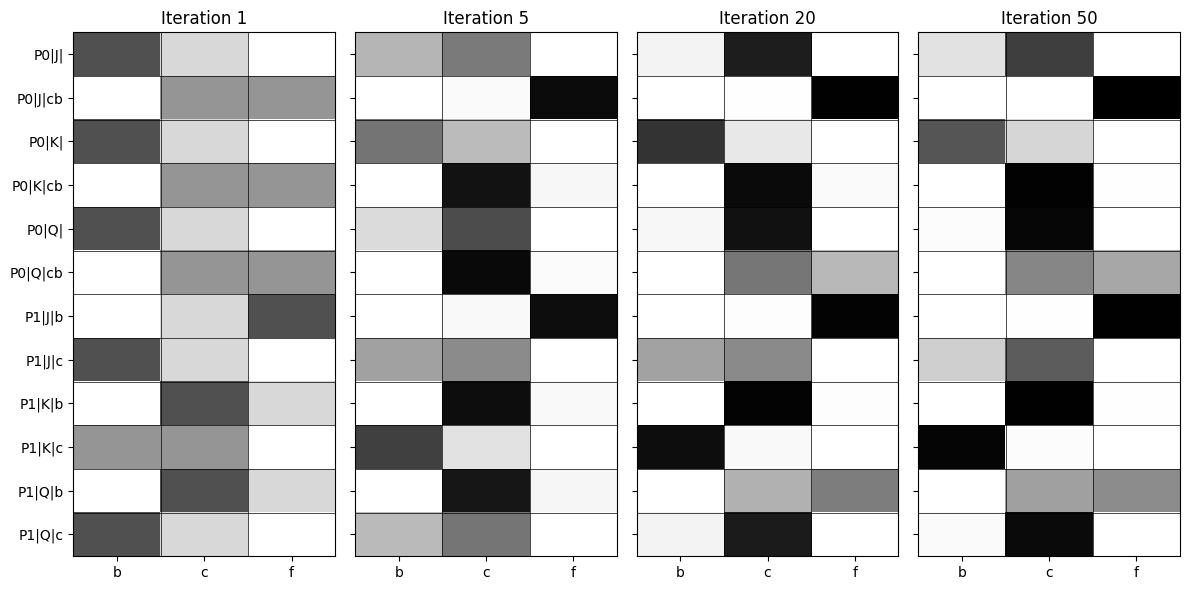

In [134]:
checkpoints = [1, 5, 20, 50, 100]

average_value, snapshots = train_cfr_with_snapshots(
    number_iterations=50,
    checkpoints=checkpoints,
)

print(f"Average training value for P0: {average_value:.4f}")
plot_strategy_evolution(snapshots)
plt.show()

### Final average policy
- This is the learned policy after the last checkpoint.
- Use this policy for play/evaluation.
- Values near `0` or `1` mean almost deterministic actions.
- Mixed values mean deliberate randomization at equilibrium.


In [124]:
final_strategy = snapshots[-1][1]
strategy_0, strategy_1 = split_strategy_by_player(final_strategy)

print("Player 0 strategy")
for key, probabilities in strategy_0.items():
    print(key, probabilities)

print("\nPlayer 1 strategy")
for key, probabilities in strategy_1.items():
    print(key, probabilities)

Player 0 strategy
P0|J| {'c': 0.8044172572281674, 'b': 0.1955827427718326}
P0|J|cb {'c': 0.003107839840003448, 'f': 0.9968921601599966}
P0|Q| {'c': 0.97625, 'b': 0.02375}
P0|Q|cb {'c': 0.5582741527350573, 'f': 0.44172584726494274}
P0|K| {'c': 0.26514890534605606, 'b': 0.7348510946539438}
P0|K|cb {'c': 0.9905713357679634, 'f': 0.009428664232036537}

Player 1 strategy
P1|Q|c {'c': 0.9616666666666667, 'b': 0.03833333333333333}
P1|Q|b {'c': 0.46731971472462824, 'f': 0.5326802852753718}
P1|K|c {'c': 0.02, 'b': 0.98}
P1|K|b {'c': 0.995, 'f': 0.005}
P1|J|c {'c': 0.7083029467921071, 'b': 0.29169705320789285}
P1|J|b {'c': 0.005, 'f': 0.995}
